In [48]:
!git clone https://github.com/Mikayla-ds2/surge-sense.git

Cloning into 'surge-sense'...
remote: Enumerating objects: 71, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 71 (delta 34), reused 49 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (71/71), 1.97 MiB | 10.66 MiB/s, done.
Resolving deltas: 100% (34/34), done.


In [49]:
!pip install --upgrade ipython
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
# dependecies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
data = pd.read_csv('/content/drive/MyDrive/cleaned-data.csv')

data = data.drop(['Unnamed: 0'], axis=1)

data.head()

,patient_id,patient_gender,patient_race,patient_age,admission_day,admission_time,patient_waittime,admission_flag,department_referral,age_category,time_category,day_of_week
0,145-39-5406,Male,White,69,2024-03-20,08:47:00,39,False,No referral.,Senior,Day,Wednesday
1,316-34-3057,Male,Native American/Alaska Native,4,2024-06-15,11:29:00,27,True,No referral.,Minor,Day,Saturday
2,897-46-3852,Female,African American,56,2024-06-20,09:13:00,55,True,General Practice,Older Adult,Day,Thursday
3,358-31-9711,Female,Native American/Alaska Native,24,2024-04-02,22:34:00,31,True,General Practice,Young Adult,Evening,Tuesday
4,289-26-0537,Male,African American,5,2024-04-09,17:48:00,10,False,Orthopedics,Minor,Evening,Tuesday


In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   patient_id           9216 non-null   object
 1   patient_gender       9216 non-null   object
 2   patient_race         9216 non-null   object
 3   patient_age          9216 non-null   int64 
 4   admission_day        9216 non-null   object
 5   admission_time       9216 non-null   object
 6   patient_waittime     9216 non-null   int64 
 7   admission_flag       9216 non-null   bool  
 8   department_referral  9216 non-null   object
 9   age_category         9216 non-null   object
 10  time_category        9216 non-null   object
 11  day_of_week          9216 non-null   object
dtypes: bool(1), int64(2), object(9)
memory usage: 801.1+ KB


In [54]:
data.describe()

,patient_age,patient_waittime
count,9216.000000,9216.000000
mean,39.855143,35.259874
std,22.755125,14.735323
min,1.000000,10.000000
25%,20.000000,23.000000
50%,39.000000,35.000000
75%,60.000000,48.000000
max,79.000000,60.000000


In [55]:
data.isnull().sum()

,0
patient_id,0
patient_gender,0
patient_race,0
patient_age,0
admission_day,0
admission_time,0
patient_waittime,0
admission_flag,0
department_referral,0
age_category,0


In [56]:
data.duplicated().sum()

np.int64(0)

In [57]:
data.shape

(9216, 12)

In [58]:
import seaborn as sns
from matplotlib.colors import ListedColormap 

In [59]:
# for all my plots
palette = ['#EAD3A9', '#84592B', '#A05135', 
           '#743015', '#462D1B', '#9D9368']
customcmap = ListedColormap(palette)

/tmp/ipykernel_585/2500626836.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x700 with 0 Axes>

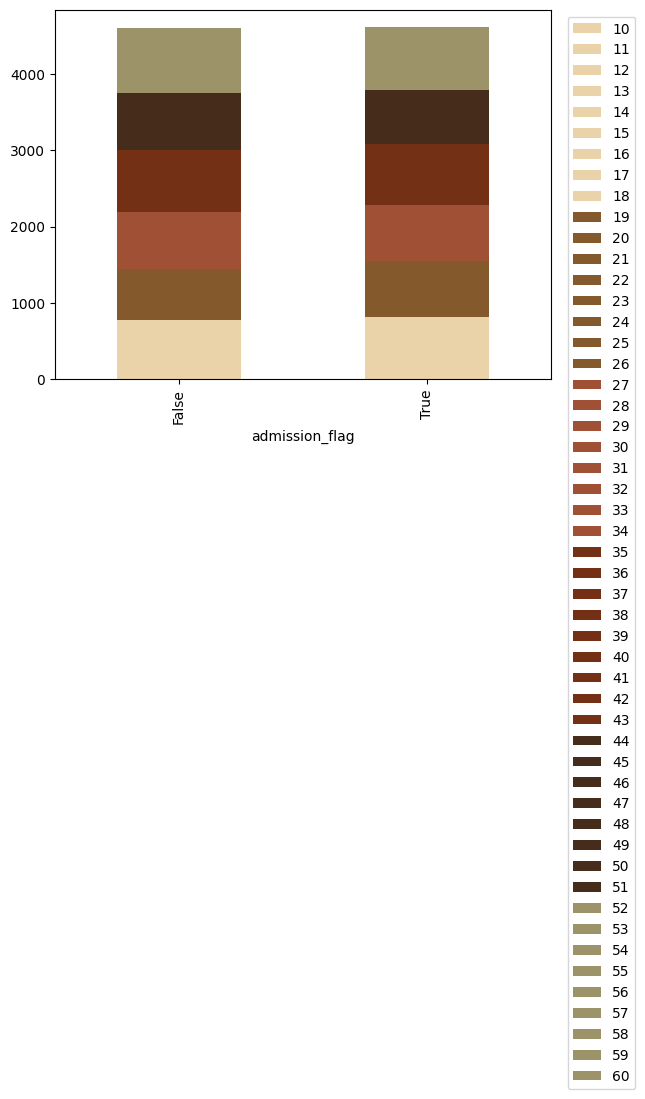

In [60]:
# creating cross table to evaluate if admission is a valuable variable
crosstab01 = pd.crosstab(data['admission_flag'], 
                         data['patient_waittime'])

plt.figure(figsize=(12, 7))
crosstab01.plot(kind='bar', stacked=True, colormap=customcmap)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

In [61]:
# determined by the previous images, admission_flag 
# has inconclusive context and 
# thus need to be excluded from any further analysis or modeling.
data = data.drop(['admission_flag'], axis=1)
data.head()

,patient_id,patient_gender,patient_race,patient_age,admission_day,admission_time,patient_waittime,department_referral,age_category,time_category,day_of_week
0,145-39-5406,Male,White,69,2024-03-20,08:47:00,39,No referral.,Senior,Day,Wednesday
1,316-34-3057,Male,Native American/Alaska Native,4,2024-06-15,11:29:00,27,No referral.,Minor,Day,Saturday
2,897-46-3852,Female,African American,56,2024-06-20,09:13:00,55,General Practice,Older Adult,Day,Thursday
3,358-31-9711,Female,Native American/Alaska Native,24,2024-04-02,22:34:00,31,General Practice,Young Adult,Evening,Tuesday
4,289-26-0537,Male,African American,5,2024-04-09,17:48:00,10,Orthopedics,Minor,Evening,Tuesday


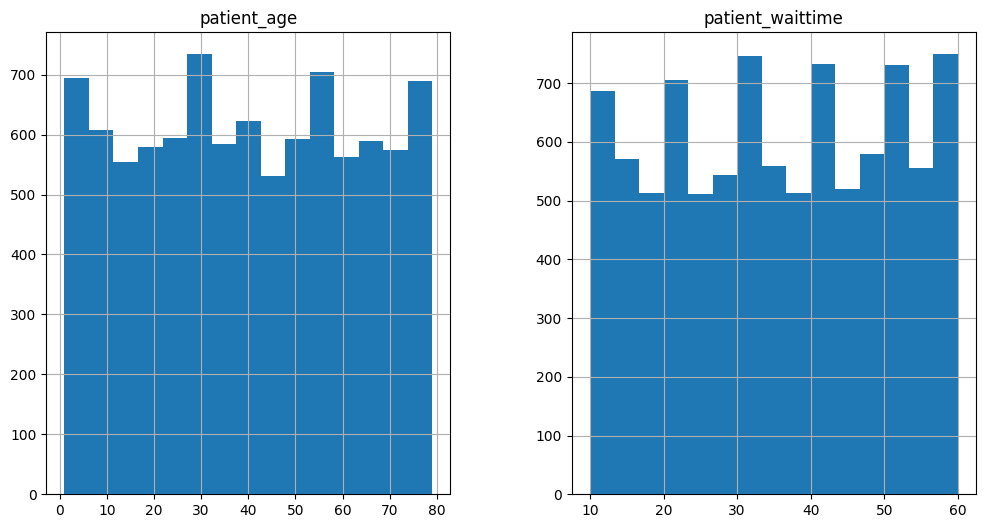

In [62]:
histogram = data.select_dtypes(
    include=['number', 'bool']).hist(bins=15, figsize=[12, 6])
plt.show()

In [63]:
%cd surge-sense
from rate_deviation import rate_deviation
from plot_rate_deviation import plot_diverging_plot, plot_confidence_heatmap

/content/surge-sense/surge-sense


In [71]:
result = rate_deviation(
    data=data,
    feature='age_category',
    outcome='department_referral',
    exclude_value='No referral.'
)

In [72]:
print(result)

RateDeviationResult(tidy=   age_category department_referral  observed_count  expected_count  \
0         Adult          Cardiology              30       30.935010   
1         Adult    Gastroenterology              23       22.203354   
2         Adult    General Practice             234      229.517820   
3         Adult           Neurology              21       24.074423   
4         Adult         Orthopedics             118      124.114256   
5         Adult       Physiotherapy              35       34.427673   
6         Adult               Renal              15       10.727463   
7   Middle-aged          Cardiology              28       29.895178   
8   Middle-aged    Gastroenterology              28       21.457023   
9   Middle-aged    General Practice             223      221.802935   
10  Middle-aged           Neurology              19       23.265199   
11  Middle-aged         Orthopedics             129      119.942348   
12  Middle-aged       Physiotherapy              23 

In [66]:
!git pull

Already up to date.


In [ ]:
print(data['patient_race'].unique())
print(data['department_referral'].unique())

In [ ]:
data['patient_race'].value_counts(normalize=True)

In [ ]:
data['department_referral'].value_counts(normalize=True)

In [ ]:
# this code allows me to only see the people who were referred to a department
referred = data.loc[data[
    'department_referral'] != 'No referral.', 'department_referral']       

In [ ]:
referred.value_counts(normalize=True)

In [ ]:
data['patient_race'].value_counts(
    normalize=True).mul(100).round(1)

In [ ]:
# is referred but adds race for proper percentage calculations
referrals = data.loc[
    data['department_referral'].ne('No referral.'),
    ['patient_race', 'department_referral']
]

# the percentage of patients of that race referred to that department
crosstab_race_dpt = (
    pd.crosstab(
        referrals['patient_race'],
        referrals['department_referral'],
        normalize='columns' # index means to sums to 100 for the row; columns for the column
    )
    .mul(100)
)
# for index: given a patient is of a certain race, what percentage of their referrals go to each department
# for columns: given a pateint was referred to a certain department, what's the racial breakdown of that department
crosstab_race_dpt.round(1)

In [ ]:
referrals['patient_race'].value_counts(
    normalize=True).mul(100).round(1)

In [ ]:
baseline = (
    referrals['department_referral'].value_counts(
        normalize=True).
    mul(100).
    reindex(crosstab_race_dpt.columns)
)

difference_pp = crosstab_race_dpt.sub(
    baseline, axis='columns')
difference_pp.round(2)

In [ ]:
print(baseline)

In [ ]:
plot_data = difference_pp.T

fig, ax = plt.subplots(figsize=(13, 7))

for race in plot_data.columns:
    values = plot_data[race]
    colors = values.map(lambda x: '#2e8b57' if x >= 0 else '#c94c4c')
    ax.barh(plot_data.index, values, left=0, alpha=0.55, color=colors)

ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Difference from overall referral baseline (percentage points)')
ax.set_ylabel('Department')
plt.tight_layout()
plt.show()

In [ ]:
department_total_difference = (
    difference_pp
    .abs()
    .sum(axis=0)
    .sort_values(ascending=False)
)

department_total_difference.round(1)

In [ ]:
race_weights = referrals['patient_race'].value_counts(normalize=True)

department_weighted_difference = (
    difference_pp
    .abs()
    .mul(race_weights, axis=0)
    .sum(axis=0)
    .sort_values(ascending=False)
)

department_weighted_difference.round(1)

In [ ]:
# Keep full precision for calculations; round only displayed labels.
difference_pp = crosstab_race_dpt.sub(baseline, axis='columns')

races = difference_pp.index
departments = difference_pp.columns
x_limit = np.ceil(difference_pp.abs().to_numpy().max() + 0.5)

fig, axes = plt.subplots(4, 2, figsize=(16, 18), sharex=True)
axes = axes.flatten()

for ax, race in zip(axes, races):
    values = difference_pp.loc[race].sort_values()
    colors = np.where(values >= 0, '#3b8f5a', '#c95050')

    ax.barh(values.index, values, color=colors)
    ax.axvline(0, color='black', linewidth=1)

    for department, value in values.items():
        label = f'{value:+.2f} pp'
        x_position = value + (0.12 if value >= 0 else -0.12)
        alignment = 'left' if value >= 0 else 'right'

        ax.text(
            x_position, department, label,
            va='center', ha=alignment, fontsize=9
        )

    ax.set_title(race)
    ax.set_xlim(-x_limit, x_limit)
    ax.set_xlabel('Difference from department baseline (percentage points)')
    ax.set_ylabel('')

# Remove the unused eighth panel.
fig.delaxes(axes[-1])

fig.suptitle(
    'Referral Distribution by Race vs. Overall Referral Baseline',
    fontsize=16,
    y=1.01
)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(13, 6))

sns.heatmap(
    difference_pp,
    annot=difference_pp.round(2),
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Difference from baseline (percentage points)'}
)

plt.xlabel('Department referral')
plt.ylabel('Patient race')
plt.title('Race-Specific Referral Mix Compared with Overall Referral Baseline')
plt.tight_layout()
plt.show()

In [ ]:
referrals_waittime = data.loc[
    data['department_referral'].ne('No referral.'),
    ['patient_waittime', 'department_referral']
]

In [ ]:
mean_values = referrals_waittime.groupby('department_referral')['patient_waittime'].mean()

plt.figure(figsize=(12, 6))
mean_values.plot(kind='bar', color=customcmap.colors)
plt.title('Average Waittime per Department Referral')
plt.xlabel('Department Referral')
plt.ylabel('Patient Waittime')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
print(data.dtypes)

In [ ]:
data.describe()

In [ ]:
columns = ['patient_race', 'patient_gender', 'age_category', 'day_of_week', 'time_category']
for col in columns:
    mean_values = data.groupby(col)['patient_waittime'].mean()

    plt.figure(figsize=(12, 6))
    mean_values.plot(kind='bar', color=customcmap.colors)
    plt.title(f"Average waittime per {col.capitalize()}")
    plt.xlabel(col.capitalize())
    plt.ylabel('Patient Waittime')
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [ ]:
mean_values = data.groupby('patient_race')['patient_age'].mean()

plt.figure(figsize=(12, 6))
mean_values.plot(kind='bar', color=customcmap.colors)
plt.title('Average Age per Patient Race')
plt.xlabel('Patient Race')
plt.ylabel('Average Age')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()